**Import Libraries**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

**Load Dataset**

In [2]:
df = pd.read_csv("Twitter_Data.csv")      # Replace with your dataset name

**View Dataset**

In [37]:
df.head()

,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


In [38]:
df.shape

(162976, 2)

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162976 entries, 0 to 162975
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   clean_text  162976 non-null  object 
 1   category    162969 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.5+ MB


In [40]:
df.describe()

,category
count,162969.000000
mean,0.225442
std,0.781279
min,-1.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


**Check for missing values**

In [41]:
df.isnull().sum()

,0
clean_text,0
category,7


In [50]:
df = df.dropna(subset=['clean_text', 'category'])
df.reset_index(drop=True, inplace=True)

**Check for class distribution**

In [42]:
df['category'].value_counts()

,count
category,
1.0,72249
0.0,55211
-1.0,35509


**Pie chart**

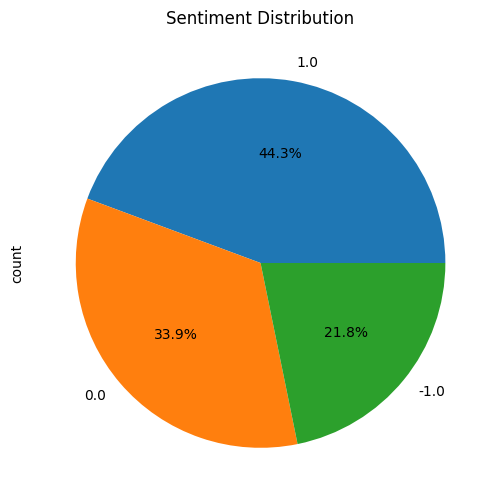

In [72]:
df['category'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)
plt.title("Sentiment Distribution")
plt.show()

**Length of tweets**

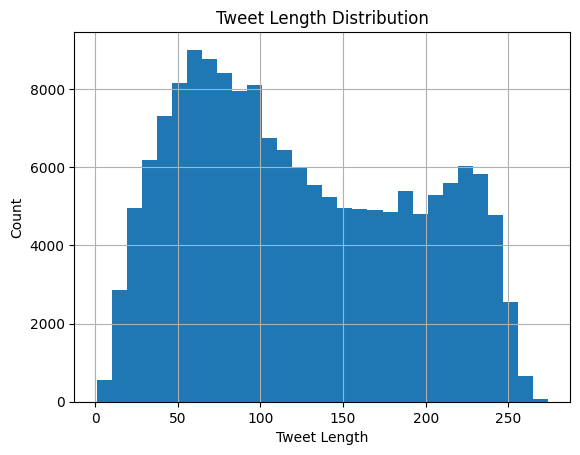

In [73]:
df['Length'] = df['clean_text'].apply(len)

df['Length'].hist(bins=30)

plt.xlabel("Tweet Length")
plt.ylabel("Count")
plt.title("Tweet Length Distribution")

plt.show()

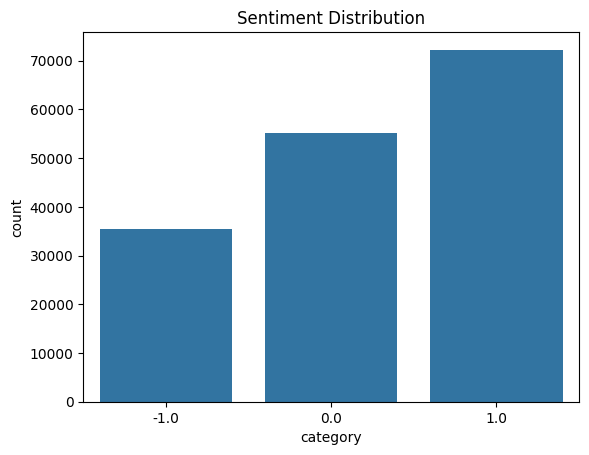

In [43]:
sns.countplot(x='category', data=df)
plt.title("Sentiment Distribution")
plt.show()

**Features and target**

In [57]:
X = df['clean_text'].astype(str)
y = df['category']

**Convert text to numbers**

In [58]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(X)

**Train test split**

In [59]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Train Model**

In [48]:
print(type(X_train))

<class 'scipy.sparse._csr.csr_matrix'>


In [60]:
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

**Prediction**

In [61]:
y_pred = model.predict(X_test)

**Accuracy**

In [62]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.5738786279683378


**Classification Report**

In [63]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        -1.0       0.92      0.13      0.23      7152
         0.0       0.84      0.34      0.49     11067
         1.0       0.52      0.97      0.67     14375

    accuracy                           0.57     32594
   macro avg       0.76      0.48      0.47     32594
weighted avg       0.72      0.57      0.51     32594



**Confusion Matrix**

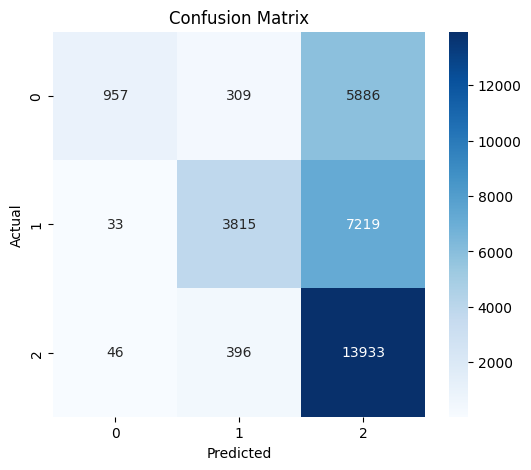

In [64]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

**Testing**

In [69]:
text = input("Enter a sentence : ")

Enter a sentence : Modi has done a great job.


In [70]:
text_vector = vectorizer.transform([text])

prediction = model.predict(text_vector)

print(prediction)

[1.]


**Show sentiment name**

In [71]:
if prediction[0] == 1:
    print("😊 Positive")

elif prediction[0] == 0:
    print("😐 Neutral")

else:
    print("😞 Negative")

😊 Positive
